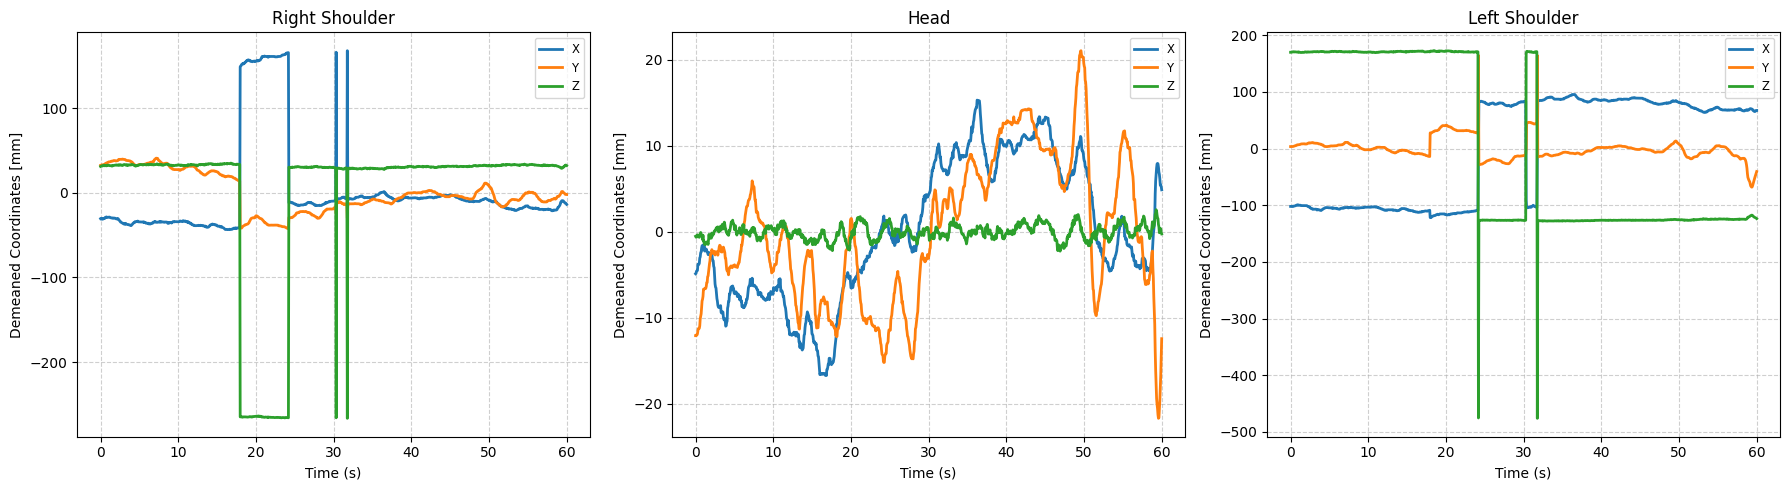

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

input_csv = ("/Volumes/Bapje_boris/Mariona/RecordingsMariona/jose3/Output_processed/transform_3d.csv")
output_folder = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/jose3/Output_processed"


# -------------------------
# PLOTTING FUNCTION
# -------------------------
def plot_to_ax(ax, data, marker_pos):
    num_points = data.shape[0]
    t = np.linspace(0, 60, num_points)  # time axis (0–60 sec)

    ax.plot(t, data[:, 0], label='X', linewidth=2)
    ax.plot(t, data[:, 1], label='Y', linewidth=2)
    ax.plot(t, data[:, 2], label='Z', linewidth=2)

    ax.set_ylabel('Demeaned Coordinates [mm]')
    ax.set_xlabel('Time (s)')
    ax.set_title(marker_pos)
    ax.legend(loc='upper right', fontsize='small')
    ax.grid(True, linestyle='--', alpha=0.6)


# -------------------------
# LOAD DATA
# -------------------------

raw_df = pd.read_csv(input_csv)

left_shoulder = raw_df[['pt1_x', 'pt1_y', 'pt1_z']]
head = raw_df[['pt2_x', 'pt2_y', 'pt2_z']]
right_shoulder = raw_df[['pt3_x', 'pt3_y', 'pt3_z']]

markers = [
    (left_shoulder, 'Right Shoulder', 'pt1'),
    (head, 'Head', 'pt2'),
    (right_shoulder, 'Left Shoulder', 'pt3')
]

# -------------------------
# CREATE SUBPLOTS
# -------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (df, name, prefix) in zip(axes, markers):
    x = df[f'{prefix}_x']
    y = df[f'{prefix}_y']
    z = df[f'{prefix}_z']

    x_norm = x - x.mean()
    y_norm = y - y.mean()
    z_norm = z - z.mean()

    data = np.vstack((x_norm, y_norm, z_norm)).T

    plot_to_ax(ax, data, name)

plt.tight_layout()
save_path = os.path.join(output_folder, 'markers_normalized.png')
plt.savefig(save_path, dpi=200)
plt.show()

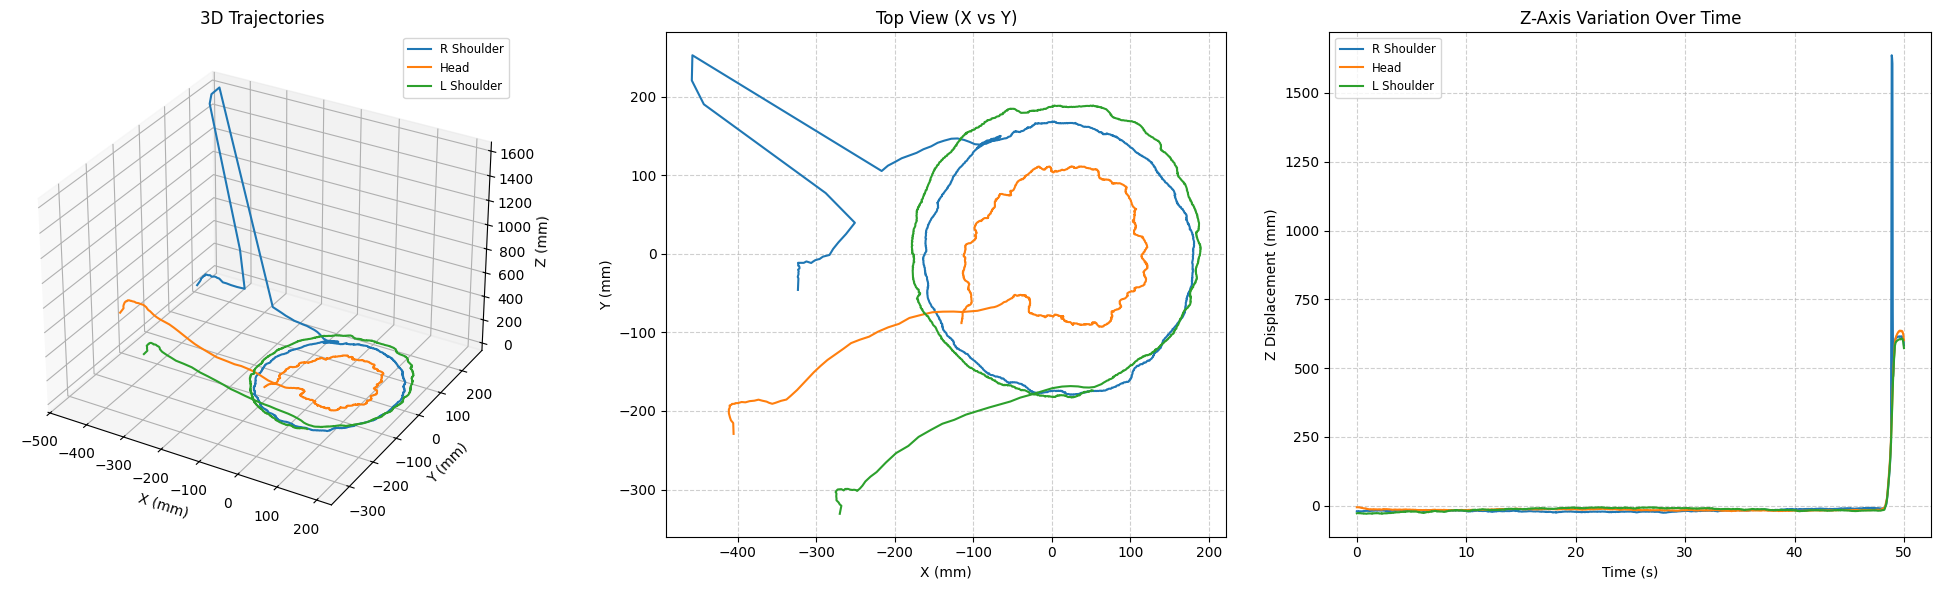

In [18]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load data and trim frames
input_csv = ("/Volumes/Bapje_boris/Mariona/RecordingsMariona/5555/Output_processed/transform_3d.csv")
df = pd.read_csv(input_csv).interpolate(method='linear').reset_index(drop=True)

# Create a time axis based on the number of frames (assuming 0 to 60 seconds as per your Code 1)
time = np.linspace(0, 50, len(df))

# 2. Setup Figure with three subplots: 1 row, 3 columns
fig = plt.figure(figsize=(20, 6))

# Subplot 1: 3D Trajectory
ax3d = fig.add_subplot(131, projection='3d')

# Subplot 2: 2D Spatial (X vs Y)
ax2d = fig.add_subplot(132)

# Subplot 3: Z-axis variation over Time
ax_z = fig.add_subplot(133)

# 3. Plot each marker
markers_info = [('pt1', 'R Shoulder'), ('pt2', 'Head'), ('pt3', 'L Shoulder')]

for pt, label in markers_info:
    # Mean-centering the data
    x = df[f'{pt}_x'] - df[f'{pt}_x'].mean()
    y = df[f'{pt}_y'] - df[f'{pt}_y'].mean()
    z = df[f'{pt}_z'] - df[f'{pt}_z'].mean()

    # 1. Add to 3D plot
    ax3d.plot(x, y, z, label=label)

    # 2. Add to 2D plot (X vs Y)
    ax2d.plot(x, y, label=label)

    # 3. Add to Z-variation plot (Time vs Z)
    ax_z.plot(time, z, label=label)

# -------------------------
# FORMATTING
# -------------------------

# 3D Plot
ax3d.set_xlabel('X (mm)')
ax3d.set_ylabel('Y (mm)')
ax3d.set_zlabel('Z (mm)')
ax3d.set_title('3D Trajectories')
ax3d.legend(fontsize='small')

# 2D Plot (X vs Y)
ax2d.set_xlabel('X (mm)')
ax2d.set_ylabel('Y (mm)')
ax2d.set_aspect('equal', adjustable='box')
ax2d.set_title('Top View (X vs Y)')
ax2d.grid(True, linestyle='--', alpha=0.6)

# Z-axis Plot (Z vs Time)
ax_z.set_xlabel('Time (s)')
ax_z.set_ylabel('Z Displacement (mm)')
ax_z.set_title('Z-Axis Variation Over Time')
ax_z.grid(True, linestyle='--', alpha=0.6)
ax_z.legend(fontsize='small')

plt.tight_layout()
plt.show()

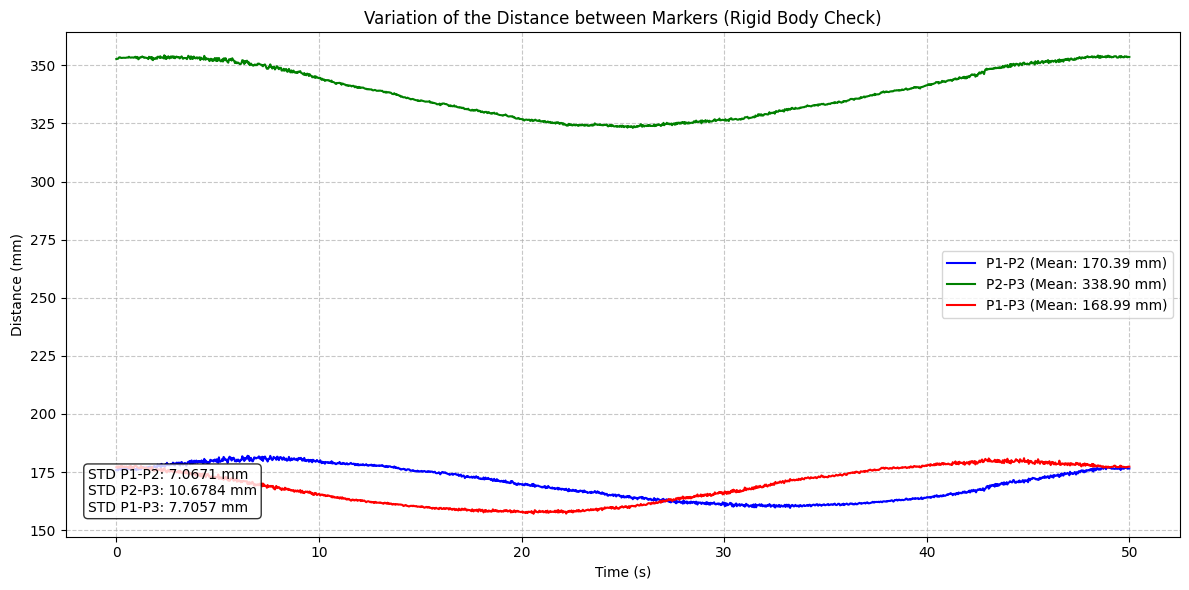

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

input_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/501/Output_processed/transform_3d.csv"
output_folder = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/501/Output_processed"

df = pd.read_csv(input_csv).interpolate(method='linear').reset_index(drop=True)
time = np.linspace(0, 50, len(df))

# -------------------------
# Eucledian Distance
# -------------------------
def calculate_distance(p1, p2):
    # sqrt((x2-x1)^2 + (y2-y1)^2 + (z2-z1)^2)
    return np.sqrt((p1[:,0] - p2[:,0])**2 + (p1[:,1] - p2[:,1])**2 + (p1[:,2] - p2[:,2])**2)

p1 = df[['pt1_x', 'pt1_y', 'pt1_z']].to_numpy()
p2 = df[['pt2_x', 'pt2_y', 'pt2_z']].to_numpy()
p3 = df[['pt3_x', 'pt3_y', 'pt3_z']].to_numpy()

dist_1_2 = calculate_distance(p1, p2)
dist_2_3 = calculate_distance(p2, p3)
dist_1_3 = calculate_distance(p1, p3)

# -------------------------
# plot distance variation
# -------------------------
plt.figure(figsize=(12, 6))

plt.plot(time, dist_1_2, label=f'P1-P2 (Mean: {dist_1_2.mean():.2f} mm)', color='blue')
plt.plot(time, dist_2_3, label=f'P2-P3 (Mean: {dist_2_3.mean():.2f} mm)', color='green')
plt.plot(time, dist_1_3, label=f'P1-P3 (Mean: {dist_1_3.mean():.2f} mm)', color='red')

plt.title('Variation of the Distance between Markers (Rigid Body Check)')
plt.xlabel('Time (s)')
plt.ylabel('Distance (mm)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Standard Deviation
info_text = (f"STD P1-P2: {dist_1_2.std():.4f} mm\n"
             f"STD P2-P3: {dist_2_3.std():.4f} mm\n"
             f"STD P1-P3: {dist_1_3.std():.4f} mm")
plt.annotate(info_text, xy=(0.02, 0.05), xycoords='axes fraction',
             bbox=dict(boxstyle="round", fc="white", alpha=0.8))

plt.tight_layout()
save_path_dist = os.path.join(output_folder, 'marker_distances.png')
plt.savefig(save_path_dist, dpi=200)
plt.show()


In [5]:
import pandas as pd

# code used to make a table with the values after plotting all the recordings

dades = {
    "Configuration": [
        "infrareds on wood 50cm",
        "infrareds on wood 70cm",
        "infrareds on wood 90cm",
        "infrareds on wood 220cm",
        "infrareds on platform 240cm",
        "infrareds on box 65cm"
    ],
    "STD P1-P2 (mm)": [7.1087, 5.9236, 1.8847, 3.1970, 2.7822, 2.6908],
    "STD P2-P3 (mm)": [10.7949, 6.5177, 4.7442, 3.2889, 2.5185, 2.5510],
    "STD P1-P3 (mm)": [7.7481, 8.7645, 5.6473, 4.9682, 3.3864, 3.2035]
}

df = pd.DataFrame(dades)

print("Error of the camera with depth")
print("=" * 33)
print(df.to_string(index=False))

Error of the camera with depth
              Configuration  STD P1-P2 (mm)  STD P2-P3 (mm)  STD P1-P3 (mm)
     infrareds on wood 50cm          7.1087         10.7949          7.7481
     infrareds on wood 70cm          5.9236          6.5177          8.7645
     infrareds on wood 90cm          1.8847          4.7442          5.6473
    infrareds on wood 220cm          3.1970          3.2889          4.9682
infrareds on platform 240cm          2.7822          2.5185          3.3864
      infrareds on box 65cm          2.6908          2.5510          3.2035


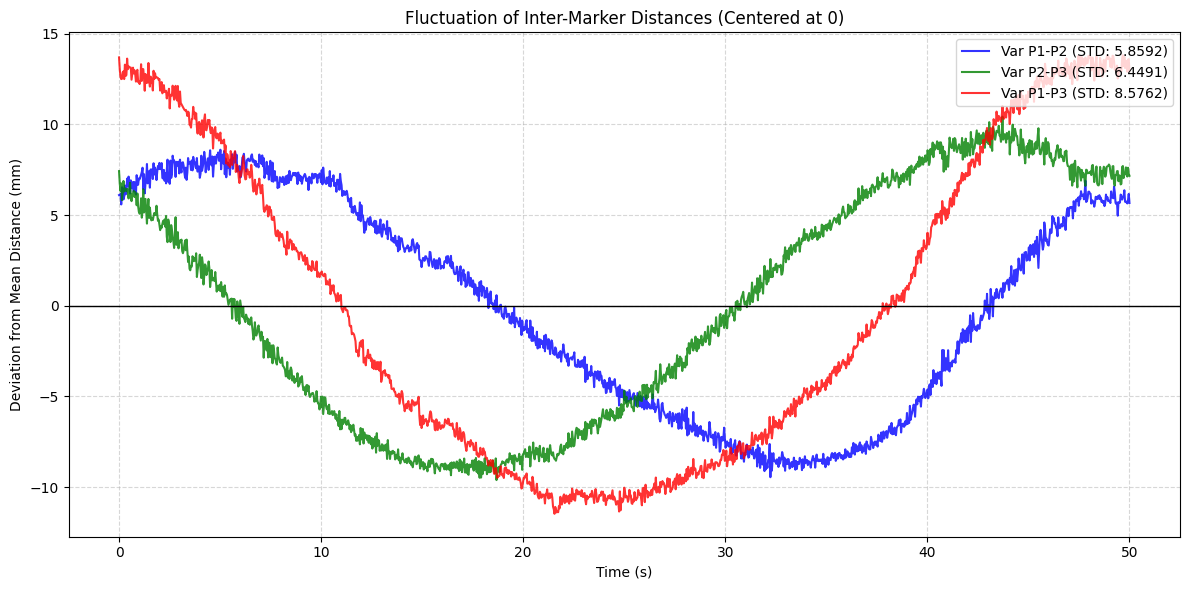

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

input_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/701/Output_processed/transform_3d.csv"
output_folder = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/501/Output_processed"

df = pd.read_csv(input_csv).interpolate(method='linear').reset_index(drop=True)
time = np.linspace(0, 50, len(df))

# -------------------------
# eucledian distance
# -------------------------
def calculate_distance(p1, p2):
    return np.sqrt((p1[:,0] - p2[:,0])**2 + (p1[:,1] - p2[:,1])**2 + (p1[:,2] - p2[:,2])**2)

p1 = df[['pt1_x', 'pt1_y', 'pt1_z']].to_numpy()
p2 = df[['pt2_x', 'pt2_y', 'pt2_z']].to_numpy()
p3 = df[['pt3_x', 'pt3_y', 'pt3_z']].to_numpy()

dist_1_2 = calculate_distance(p1, p2)
dist_2_3 = calculate_distance(p2, p3)
dist_1_3 = calculate_distance(p1, p3)

# -------------------------
# NORMALITZATION (CENTERED EN 0)
# -------------------------
dist_1_2_centered = dist_1_2 - dist_1_2.mean()
dist_2_3_centered = dist_2_3 - dist_2_3.mean()
dist_1_3_centered = dist_1_3 - dist_1_3.mean()

plt.figure(figsize=(12, 6))

plt.plot(time, dist_1_2_centered, label=f'Var P1-P2 (STD: {dist_1_2.std():.4f})', color='blue', alpha=0.8)
plt.plot(time, dist_2_3_centered, label=f'Var P2-P3 (STD: {dist_2_3.std():.4f})', color='green', alpha=0.8)
plt.plot(time, dist_1_3_centered, label=f'Var P1-P3 (STD: {dist_1_3.std():.4f})', color='red', alpha=0.8)

# REFERENCE LINE 0
plt.axhline(0, color='black', linestyle='-', linewidth=1)

plt.title('Fluctuation of Inter-Marker Distances (Centered at 0)')
plt.xlabel('Time (s)')
plt.ylabel('Deviation from Mean Distance (mm)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')


plt.tight_layout()
save_path_dist = os.path.join(output_folder, 'marker_distances_centered.png')
plt.savefig(save_path_dist, dpi=200)
plt.show()

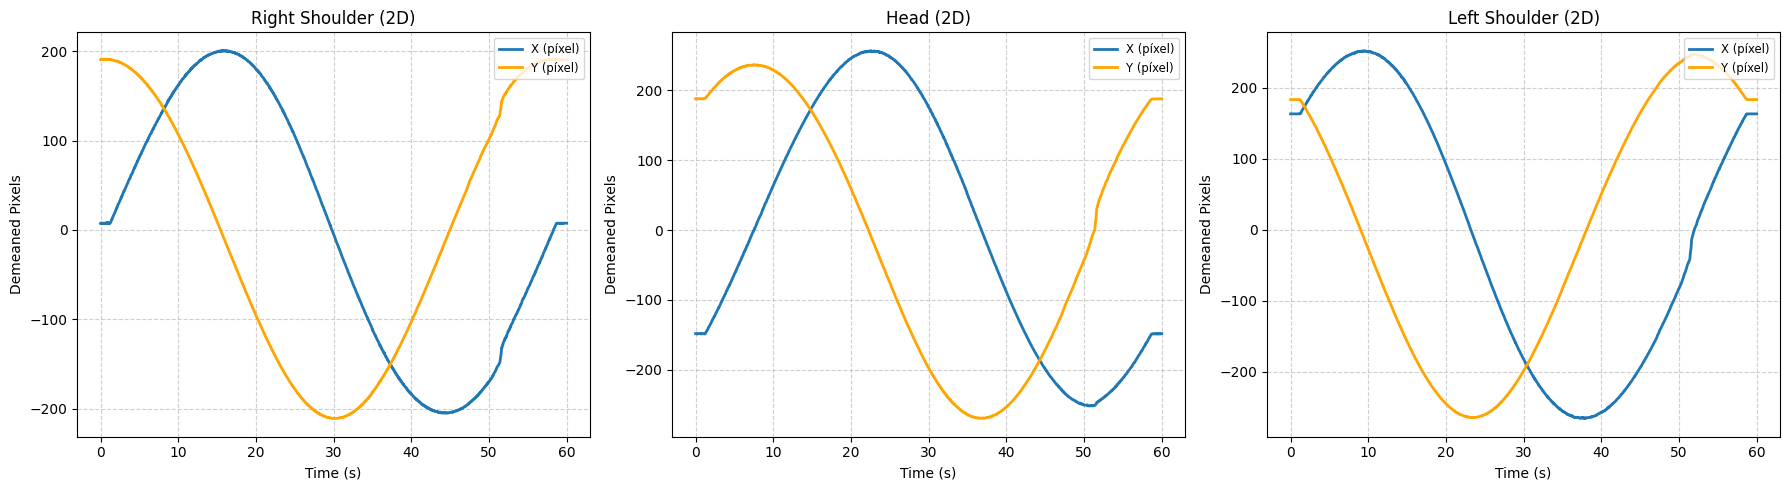

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

input_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/501/Output_processed/centers_2d.csv"
output_folder = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/501/Output_processed"


# -------------------------
# PLOTTING FUNCTION
# -------------------------
def plot_to_ax(ax, data, marker_pos):
    num_points = data.shape[0]
    t = np.linspace(0, 60, num_points)

    ax.plot(t, data[:, 0], label='X (píxel)', linewidth=2)
    ax.plot(t, data[:, 1], label='Y (píxel)', linewidth=2, color='orange')

    ax.set_ylabel('Demeaned Pixels')
    ax.set_xlabel('Time (s)')
    ax.set_title(f"{marker_pos} (2D)")
    ax.legend(loc='upper right', fontsize='small')
    ax.grid(True, linestyle='--', alpha=0.6)


# -------------------------
# LOAD DATA
# -------------------------

raw_df = pd.read_csv(input_csv)

left_shoulder = raw_df[['pt1_x', 'pt1_y']]
head = raw_df[['pt2_x', 'pt2_y']]
right_shoulder = raw_df[['pt3_x', 'pt3_y']]

markers = [
    (left_shoulder, 'Right Shoulder', 'pt1'),
    (head, 'Head', 'pt2'),
    (right_shoulder, 'Left Shoulder', 'pt3')
]

# -------------------------
# CREATE SUBPLOTS
# -------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (df, name, prefix) in zip(axes, markers):
    x = df[f'{prefix}_x']
    y = df[f'{prefix}_y']

    x_norm = x - x.mean()
    y_norm = y - y.mean()

    data = np.vstack((x_norm, y_norm)).T

    plot_to_ax(ax, data, name)

plt.tight_layout()
save_path = os.path.join(output_folder, 'markers_2d_normalized.png')
plt.savefig(save_path, dpi=200)
plt.show()


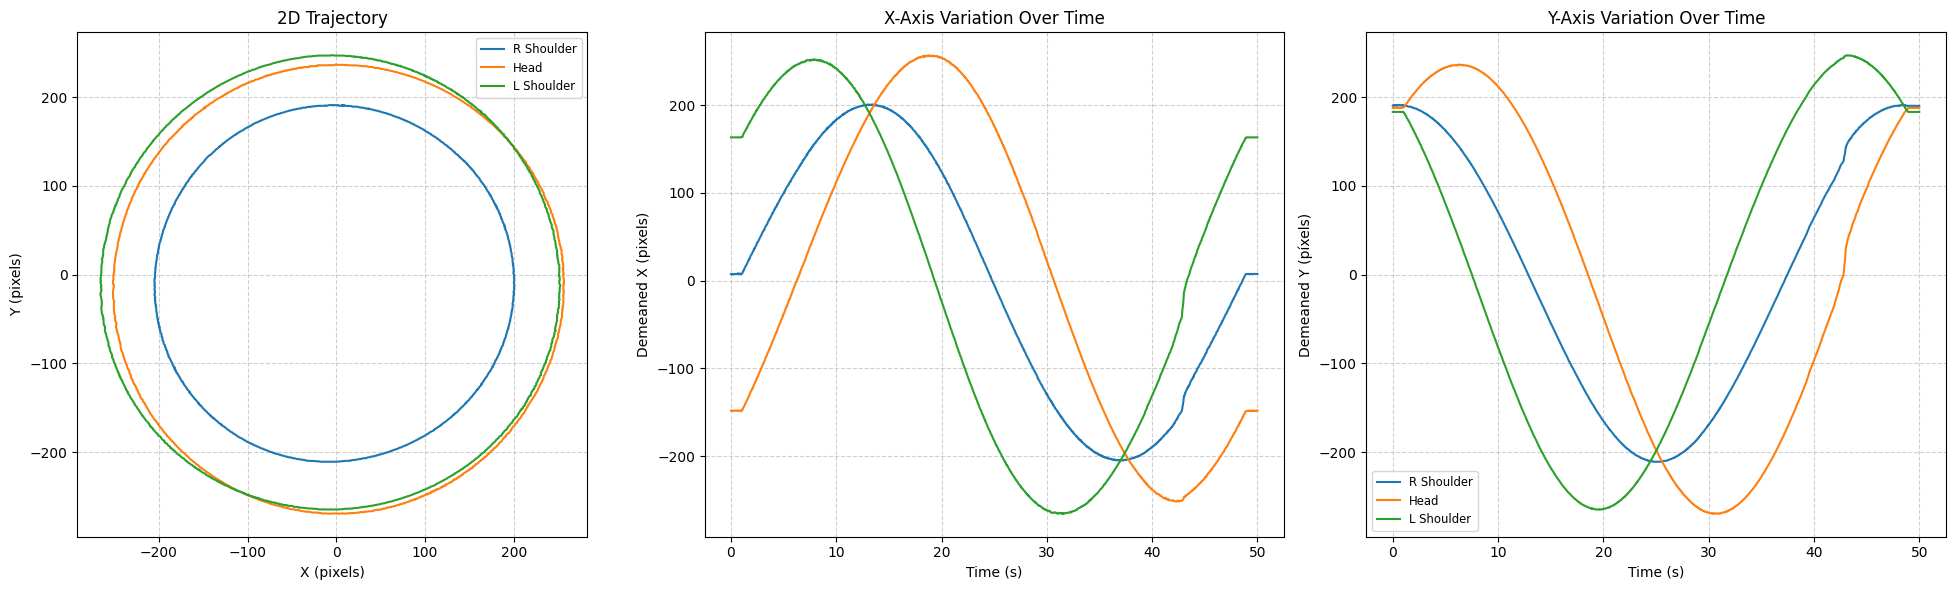

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

input_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/501/Output_processed/centers_2d.csv"
df = pd.read_csv(input_csv).interpolate(method='linear').reset_index(drop=True)

time = np.linspace(0, 50, len(df))
fig, (ax_spatial, ax_x_t, ax_y_t) = plt.subplots(1, 3, figsize=(20, 6))
markers_info = [('pt1', 'R Shoulder'), ('pt2', 'Head'), ('pt3', 'L Shoulder')]

for pt, label in markers_info:
    x = df[f'{pt}_x'] - df[f'{pt}_x'].mean()
    y = df[f'{pt}_y'] - df[f'{pt}_y'].mean()

    ax_spatial.plot(x, y, label=label)
    ax_x_t.plot(time, x, label=label)
    ax_y_t.plot(time, y, label=label)

# -------------------------
# FORMATTING
# -------------------------

# Gràfic Espacial 2D
ax_spatial.set_xlabel('X (pixels)')
ax_spatial.set_ylabel('Y (pixels)')
ax_spatial.set_aspect('equal', adjustable='box')
ax_spatial.set_title('2D Trajectory')
ax_spatial.grid(True, linestyle='--', alpha=0.6)
ax_spatial.legend(fontsize='small')

# Gràfic X vs Temps
ax_x_t.set_xlabel('Time (s)')
ax_x_t.set_ylabel('Demeaned X (pixels)')
ax_x_t.set_title('X-Axis Variation Over Time')
ax_x_t.grid(True, linestyle='--', alpha=0.6)

# Gràfic Y vs Temps
ax_y_t.set_xlabel('Time (s)')
ax_y_t.set_ylabel('Demeaned Y (píxels)')
ax_y_t.set_title('Y-Axis Variation Over Time')
ax_y_t.grid(True, linestyle='--', alpha=0.6)
ax_y_t.legend(fontsize='small')

plt.tight_layout()
plt.show()

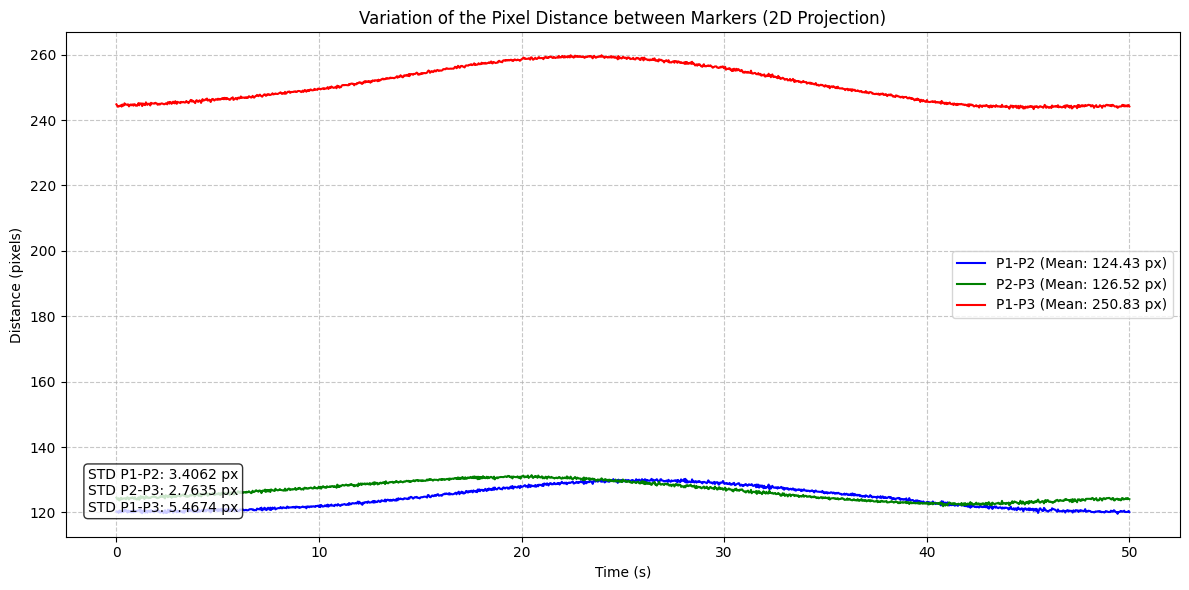

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

input_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/701/Output_processed/centers_2d.csv"
output_folder = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/501/Output_processed"

df = pd.read_csv(input_csv).interpolate(method='linear').reset_index(drop=True)
time = np.linspace(0, 50, len(df))


# -------------------------
# Distància Euclidiana 2D
# -------------------------
def calculate_distance_2d(p1, p2):
    # sqrt((x2-x1)^2 + (y2-y1)^2)
    return np.sqrt((p1[:, 0] - p2[:, 0]) ** 2 + (p1[:, 1] - p2[:, 1]) ** 2)


p1 = df[['pt1_x', 'pt1_y']].to_numpy()
p2 = df[['pt2_x', 'pt2_y']].to_numpy()
p3 = df[['pt3_x', 'pt3_y']].to_numpy()

dist_1_2 = calculate_distance_2d(p1, p2)
dist_2_3 = calculate_distance_2d(p2, p3)
dist_1_3 = calculate_distance_2d(p1, p3)

# -------------------------
# Plot de la variació de distància
# -------------------------
plt.figure(figsize=(12, 6))

plt.plot(time, dist_1_2, label=f'P1-P2 (Mean: {dist_1_2.mean():.2f} px)', color='blue')
plt.plot(time, dist_2_3, label=f'P2-P3 (Mean: {dist_2_3.mean():.2f} px)', color='green')
plt.plot(time, dist_1_3, label=f'P1-P3 (Mean: {dist_1_3.mean():.2f} px)', color='red')

plt.title('Variation of the Pixel Distance between Markers (2D Projection)')
plt.xlabel('Time (s)')
plt.ylabel('Distance (pixels)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

info_text = (f"STD P1-P2: {dist_1_2.std():.4f} px\n"
             f"STD P2-P3: {dist_2_3.std():.4f} px\n"
             f"STD P1-P3: {dist_1_3.std():.4f} px")
plt.annotate(info_text, xy=(0.02, 0.05), xycoords='axes fraction',
             bbox=dict(boxstyle="round", fc="white", alpha=0.8))

plt.tight_layout()
save_path_dist = os.path.join(output_folder, 'marker_distances_2d.png')
plt.savefig(save_path_dist, dpi=200)
plt.show()


In [10]:
import pandas as pd

# code used to make a table with the values after plotting all the recordings

dades = {
    "Configuration": [
        "infrareds on wood 50cm",
        "infrareds on wood 70cm",
        "infrareds on wood 90cm",
        "infrareds on wood 220cm",
        "infrareds on platform 240cm",
        "infrareds on box 65cm"
    ],
    "STD P1-P2 (px)": [7.1678, 3.4062, 0.8997, 0.1770, 0.3591, 0.6802],
    "STD P2-P3 (px)": [10.9653, 2.7635, 1.4984, 0.3547, 0.3057, 0.9225],
    "STD P1-P3 (px)": [5.8110, 5.4674, 2.2409, 0.4402, 0.3380, 0.9523]
}

df = pd.DataFrame(dades)

print("Error of the camera without depth (extracting data from centers_2d.csv):")
print("=" * 33)
print(df.to_string(index=False))

Error of the camera without depth (extracting data from centers_2d.csv):
              Configuration  STD P1-P2 (px)  STD P2-P3 (px)  STD P1-P3 (px)
     infrareds on wood 50cm          7.1678         10.9653          5.8110
     infrareds on wood 70cm          3.4062          2.7635          5.4674
     infrareds on wood 90cm          0.8997          1.4984          2.2409
    infrareds on wood 220cm          0.1770          0.3547          0.4402
infrareds on platform 240cm          0.3591          0.3057          0.3380
      infrareds on box 65cm          0.6802          0.9225          0.9523


In [11]:
import pandas as pd

# Convert px to mm

data_px = {
    "Configuration": [
        "infrareds on wood 50cm",
        "infrareds on wood 70cm",
        "infrareds on wood 90cm",
        "infrareds on wood 220cm",
        "infrareds on platform 240cm",
        "infrareds on box 65cm"
    ],
    "STD P1-P2 (px)": [7.1678, 3.4062, 0.8997, 0.1770, 0.3591, 0.6802],
    "STD P2-P3 (px)": [10.9653, 2.7635, 1.4984, 0.3547, 0.3057, 0.9225],
    "STD P1-P3 (px)": [5.8110, 5.4674, 2.2409, 0.4402, 0.3380, 0.9523]
}

df_px = pd.DataFrame(data_px)

# Conversion factor calculation
# Given: 5 px = 10 mm -> 1 px = 2 mm
conversion_factor = 2.0

df_mm = pd.DataFrame()
df_mm["Configuration"] = df_px["Configuration"]

df_mm["STD P1-P2 (mm)"] = df_px["STD P1-P2 (px)"] * conversion_factor
df_mm["STD P2-P3 (mm)"] = df_px["STD P2-P3 (px)"] * conversion_factor
df_mm["STD P1-P3 (mm)"] = df_px["STD P1-P3 (px)"] * conversion_factor

print("=== Converted 2D Camera Error Table (in mm) ===")
print(df_mm.to_string(index=False, formatters={
    "STD P1-P2 (mm)": "{:.4f}".format,
    "STD P2-P3 (mm)": "{:.4f}".format,
    "STD P1-P3 (mm)": "{:.4f}".format
}))

=== Converted 2D Camera Error Table (in mm) ===
              Configuration STD P1-P2 (mm) STD P2-P3 (mm) STD P1-P3 (mm)
     infrareds on wood 50cm        14.3356        21.9306        11.6220
     infrareds on wood 70cm         6.8124         5.5270        10.9348
     infrareds on wood 90cm         1.7994         2.9968         4.4818
    infrareds on wood 220cm         0.3540         0.7094         0.8804
infrareds on platform 240cm         0.7182         0.6114         0.6760
      infrareds on box 65cm         1.3604         1.8450         1.9046
